In [83]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [84]:
data = pd.read_csv('laptopData.csv')

In [85]:
data.head(5)

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1.0,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2.0,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3.0,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [86]:
data.shape

(1303, 12)

In [87]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1273 non-null   float64
 1   Company           1273 non-null   str    
 2   TypeName          1273 non-null   str    
 3   Inches            1273 non-null   str    
 4   ScreenResolution  1273 non-null   str    
 5   Cpu               1273 non-null   str    
 6   Ram               1273 non-null   str    
 7   Memory            1273 non-null   str    
 8   Gpu               1273 non-null   str    
 9   OpSys             1273 non-null   str    
 10  Weight            1273 non-null   str    
 11  Price             1273 non-null   float64
dtypes: float64(2), str(10)
memory usage: 122.3 KB


In [88]:
data.drop(['Unnamed: 0'], axis=1, inplace=True)

In [89]:
data.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [90]:
data.drop(['ScreenResolution'], axis=1, inplace=True)

In [91]:
data.drop(['TypeName'], axis=1, inplace=True)

In [92]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Company  1273 non-null   str    
 1   Inches   1273 non-null   str    
 2   Cpu      1273 non-null   str    
 3   Ram      1273 non-null   str    
 4   Memory   1273 non-null   str    
 5   Gpu      1273 non-null   str    
 6   OpSys    1273 non-null   str    
 7   Weight   1273 non-null   str    
 8   Price    1273 non-null   float64
dtypes: float64(1), str(8)
memory usage: 91.7 KB


In [93]:
data.shape

(1303, 9)

In [94]:
data['Company'].isnull().sum()

np.int64(30)

In [95]:
data['Company'].apply(lambda x:  'macOS' if x == 'apple' else ('Windows' if x == 'hp' else 'Windows'))

0       Windows
1       Windows
2       Windows
3       Windows
4       Windows
         ...   
1298    Windows
1299    Windows
1300    Windows
1301    Windows
1302    Windows
Name: Company, Length: 1303, dtype: str

In [96]:
data['OpSys'].apply(lambda x:  'Apple' if x == 'macOS' else 'win os')

0        Apple
1        Apple
2       win os
3        Apple
4        Apple
         ...  
1298    win os
1299    win os
1300    win os
1301    win os
1302    win os
Name: OpSys, Length: 1303, dtype: str

In [97]:
data = data.dropna(subset=['Ram'])

In [98]:
data['Ram'].isnull().sum()

np.int64(0)

In [99]:
data['Ram'] = data['Ram'].str.replace('GB', '').astype(int)

In [100]:
data['Memory'] = data['Memory'].str.replace('SSD', '')

In [101]:
data['Memory'] = data['Memory'].str.replace('GB', '')

In [102]:
data['Memory(GB)'] = data["Memory"]

In [103]:
data['Ram(GB)'] = data['Ram']

In [104]:
data.drop(['Memory', 'Ram'], axis=1, inplace=True)

In [105]:
data['Price'].astype(int)

0        71378
1        47895
2        30636
3       135195
4        96095
         ...  
1298     33992
1299     79866
1300     12201
1301     40705
1302     19660
Name: Price, Length: 1273, dtype: int64

In [106]:
data['Weight(KG)'] = data['Weight'].str.replace('kg', '')

In [107]:
data.drop(['Weight'], axis=1, inplace=True)

In [108]:
data['OpSys'].value_counts()

OpSys
Windows 10      1047
No OS             63
Linux             61
Windows 7         45
Chrome OS         27
macOS             13
Mac OS X           8
Windows 10 S       8
Android            1
Name: count, dtype: int64

In [109]:
data['Memory(GB)'] = data['Memory(GB)'].str.replace('Flash Storage', '')

In [110]:
data['Memory(GB)'] = data['Memory(GB)'].str.replace('Hybrid', '')

In [111]:
data['Memory(GB)'] = data['Memory(GB)'].str.replace('HDD', '')

In [112]:
data['Memory(GB)'].value_counts()

Memory(GB)
256               409
1TB               230
500               130
512               118
128  +  1TB        92
128                79
256  +  1TB        71
32                 44
2TB                16
64                 15
512  +  1TB        14
256  +  2TB        10
1.0TB              10
16                 10
180                 4
512  +  2TB         3
1TB  +  1TB         3
256  +  256         2
256  +  500         2
128  +  2TB         2
512  +  512         1
512  +  256         1
64  +  1TB          1
?                   1
240                 1
8                   1
508                 1
512  +  1.0TB       1
256  +  1.0TB       1
Name: count, dtype: int64

In [124]:


data['Memory(GB)'] = data['Memory(GB)'].str.replace('TB', '000')

data['SSD'] = data['Memory(GB)'].str.extract(r'(\d+)\s*(?:SSD|Flash|$)')
data['HDD'] = data['Memory(GB)'].str.extract(r'(\d+)\s*HDD')

data['SSD'] = data['SSD'].fillna(0).astype(int)
data['HDD'] = data['HDD'].fillna(0).astype(int)

In [127]:
data.drop(["HDD"],axis=1,inplace=True)

In [114]:
data['Memory(GB)'].value_counts()

Memory(GB)
256                409
1000               230
500                130
512                118
128  +  1000        92
128                 79
256  +  1000        71
32                  44
2000                16
64                  15
512  +  1000        14
256  +  2000        10
1.0000              10
16                  10
180                  4
512  +  2000         3
1000  +  1000        3
256  +  256          2
256  +  500          2
128  +  2000         2
512  +  512          1
512  +  256          1
64  +  1000          1
?                    1
240                  1
8                    1
508                  1
512  +  1.0000       1
256  +  1.0000       1
Name: count, dtype: int64

In [115]:
data.head(5)

,Company,Inches,Cpu,Gpu,OpSys,Price,Memory(GB),Ram(GB),Weight(KG),SSD,HDD
0,Apple,13.3,Intel Core i5 2.3GHz,Intel Iris Plus Graphics 640,macOS,71378.6832,128,8,1.37,128,0
1,Apple,13.3,Intel Core i5 1.8GHz,Intel HD Graphics 6000,macOS,47895.5232,128,8,1.34,128,0
2,HP,15.6,Intel Core i5 7200U 2.5GHz,Intel HD Graphics 620,No OS,30636.0000,256,8,1.86,256,0
3,Apple,15.4,Intel Core i7 2.7GHz,AMD Radeon Pro 455,macOS,135195.3360,512,16,1.83,512,0
4,Apple,13.3,Intel Core i5 3.1GHz,Intel Iris Plus Graphics 650,macOS,96095.8080,256,8,1.37,256,0


In [116]:
data.info()

<class 'pandas.DataFrame'>
Index: 1273 entries, 0 to 1302
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Company     1273 non-null   str    
 1   Inches      1273 non-null   str    
 2   Cpu         1273 non-null   str    
 3   Gpu         1273 non-null   str    
 4   OpSys       1273 non-null   str    
 5   Price       1273 non-null   float64
 6   Memory(GB)  1273 non-null   str    
 7   Ram(GB)     1273 non-null   int64  
 8   Weight(KG)  1273 non-null   str    
 9   SSD         1273 non-null   int64  
 10  HDD         1273 non-null   int64  
dtypes: float64(1), int64(3), str(7)
memory usage: 119.3 KB


In [117]:
data.shape

(1273, 11)

In [118]:
data.head()

,Company,Inches,Cpu,Gpu,OpSys,Price,Memory(GB),Ram(GB),Weight(KG),SSD,HDD
0,Apple,13.3,Intel Core i5 2.3GHz,Intel Iris Plus Graphics 640,macOS,71378.6832,128,8,1.37,128,0
1,Apple,13.3,Intel Core i5 1.8GHz,Intel HD Graphics 6000,macOS,47895.5232,128,8,1.34,128,0
2,HP,15.6,Intel Core i5 7200U 2.5GHz,Intel HD Graphics 620,No OS,30636.0000,256,8,1.86,256,0
3,Apple,15.4,Intel Core i7 2.7GHz,AMD Radeon Pro 455,macOS,135195.3360,512,16,1.83,512,0
4,Apple,13.3,Intel Core i5 3.1GHz,Intel Iris Plus Graphics 650,macOS,96095.8080,256,8,1.37,256,0


In [119]:
data['Price']= data['Price'].astype(int)

In [120]:
data.head()

,Company,Inches,Cpu,Gpu,OpSys,Price,Memory(GB),Ram(GB),Weight(KG),SSD,HDD
0,Apple,13.3,Intel Core i5 2.3GHz,Intel Iris Plus Graphics 640,macOS,71378,128,8,1.37,128,0
1,Apple,13.3,Intel Core i5 1.8GHz,Intel HD Graphics 6000,macOS,47895,128,8,1.34,128,0
2,HP,15.6,Intel Core i5 7200U 2.5GHz,Intel HD Graphics 620,No OS,30636,256,8,1.86,256,0
3,Apple,15.4,Intel Core i7 2.7GHz,AMD Radeon Pro 455,macOS,135195,512,16,1.83,512,0
4,Apple,13.3,Intel Core i5 3.1GHz,Intel Iris Plus Graphics 650,macOS,96095,256,8,1.37,256,0


In [121]:
data.head()

,Company,Inches,Cpu,Gpu,OpSys,Price,Memory(GB),Ram(GB),Weight(KG),SSD,HDD
0,Apple,13.3,Intel Core i5 2.3GHz,Intel Iris Plus Graphics 640,macOS,71378,128,8,1.37,128,0
1,Apple,13.3,Intel Core i5 1.8GHz,Intel HD Graphics 6000,macOS,47895,128,8,1.34,128,0
2,HP,15.6,Intel Core i5 7200U 2.5GHz,Intel HD Graphics 620,No OS,30636,256,8,1.86,256,0
3,Apple,15.4,Intel Core i7 2.7GHz,AMD Radeon Pro 455,macOS,135195,512,16,1.83,512,0
4,Apple,13.3,Intel Core i5 3.1GHz,Intel Iris Plus Graphics 650,macOS,96095,256,8,1.37,256,0


HDD
0    1273
Name: count, dtype: int64

In [122]:
data.head()

,Company,Inches,Cpu,Gpu,OpSys,Price,Memory(GB),Ram(GB),Weight(KG),SSD,HDD
0,Apple,13.3,Intel Core i5 2.3GHz,Intel Iris Plus Graphics 640,macOS,71378,128,8,1.37,128,0
1,Apple,13.3,Intel Core i5 1.8GHz,Intel HD Graphics 6000,macOS,47895,128,8,1.34,128,0
2,HP,15.6,Intel Core i5 7200U 2.5GHz,Intel HD Graphics 620,No OS,30636,256,8,1.86,256,0
3,Apple,15.4,Intel Core i7 2.7GHz,AMD Radeon Pro 455,macOS,135195,512,16,1.83,512,0
4,Apple,13.3,Intel Core i5 3.1GHz,Intel Iris Plus Graphics 650,macOS,96095,256,8,1.37,256,0


In [128]:
data.head()

,Company,Inches,Cpu,Gpu,OpSys,Price,Memory(GB),Ram(GB),Weight(KG),SSD
0,Apple,13.3,Intel Core i5 2.3GHz,Intel Iris Plus Graphics 640,macOS,71378,128,8,1.37,128
1,Apple,13.3,Intel Core i5 1.8GHz,Intel HD Graphics 6000,macOS,47895,128,8,1.34,128
2,HP,15.6,Intel Core i5 7200U 2.5GHz,Intel HD Graphics 620,No OS,30636,256,8,1.86,256
3,Apple,15.4,Intel Core i7 2.7GHz,AMD Radeon Pro 455,macOS,135195,512,16,1.83,512
4,Apple,13.3,Intel Core i5 3.1GHz,Intel Iris Plus Graphics 650,macOS,96095,256,8,1.37,256


In [135]:
data.drop(['Memory(GB)'], axis=1, inplace=True)

In [136]:
data.head(5)

,Company,Inches,Cpu,Gpu,OpSys,Price,Ram(GB),Weight(KG),SSD
0,Apple,13.3,Intel Core i5 2.3GHz,Intel Iris Plus Graphics 640,macOS,71378,8,1.37,128
1,Apple,13.3,Intel Core i5 1.8GHz,Intel HD Graphics 6000,macOS,47895,8,1.34,128
2,HP,15.6,Intel Core i5 7200U 2.5GHz,Intel HD Graphics 620,No OS,30636,8,1.86,256
3,Apple,15.4,Intel Core i7 2.7GHz,AMD Radeon Pro 455,macOS,135195,16,1.83,512
4,Apple,13.3,Intel Core i5 3.1GHz,Intel Iris Plus Graphics 650,macOS,96095,8,1.37,256


In [138]:
data["HDD"] = data["Price"].apply(lambda x: 1024 if x > 30000 else (512 if 20000 < x <= 30000 else 0))

In [139]:
data.head()

,Company,Inches,Cpu,Gpu,OpSys,Price,Ram(GB),Weight(KG),SSD,HDD
0,Apple,13.3,Intel Core i5 2.3GHz,Intel Iris Plus Graphics 640,macOS,71378,8,1.37,128,1024
1,Apple,13.3,Intel Core i5 1.8GHz,Intel HD Graphics 6000,macOS,47895,8,1.34,128,1024
2,HP,15.6,Intel Core i5 7200U 2.5GHz,Intel HD Graphics 620,No OS,30636,8,1.86,256,1024
3,Apple,15.4,Intel Core i7 2.7GHz,AMD Radeon Pro 455,macOS,135195,16,1.83,512,1024
4,Apple,13.3,Intel Core i5 3.1GHz,Intel Iris Plus Graphics 650,macOS,96095,8,1.37,256,1024


In [152]:
data['Company'].value_counts()

Company
Lenovo       290
Dell         287
HP           266
Asus         156
Acer         103
MSI           53
Toshiba       47
Apple         21
Samsung        9
Razer          7
Mediacom       7
Microsoft      6
Xiaomi         4
Vero           4
Chuwi          3
Google         3
LG             3
Huawei         2
Fujitsu        2
Name: count, dtype: int64

In [155]:
data.head()

,Company,Inches,Cpu,Gpu,OpSys,Price,Ram(GB),Weight(KG),SSD,HDD
0,Apple,13.3,Intel Core i5 2.3GHz,Intel Iris Plus Graphics 640,macOS,71378,8,1.37,128,1024
1,Apple,13.3,Intel Core i5 1.8GHz,Intel HD Graphics 6000,macOS,47895,8,1.34,128,1024
2,HP,15.6,Intel Core i5 7200U 2.5GHz,Intel HD Graphics 620,No OS,30636,8,1.86,256,1024
3,Apple,15.4,Intel Core i7 2.7GHz,AMD Radeon Pro 455,macOS,135195,16,1.83,512,1024
4,Apple,13.3,Intel Core i5 3.1GHz,Intel Iris Plus Graphics 650,macOS,96095,8,1.37,256,1024


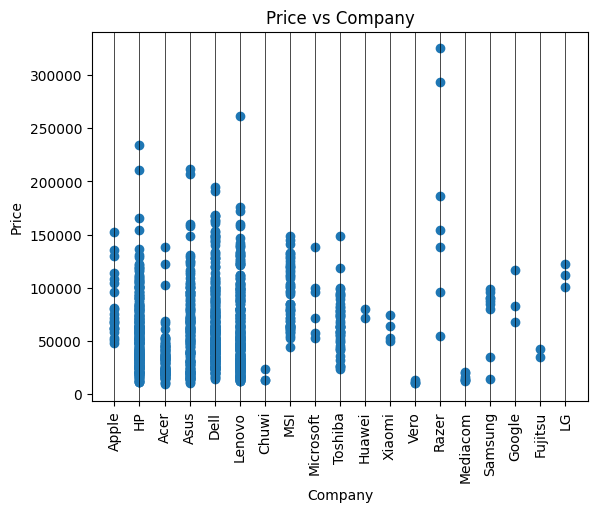

In [174]:
x = data['Company']
y = data['Price']

plt.scatter(x, y)
plt.grid(axis='x',linewidth=0.5,color='Black')
plt.xticks(rotation=90)
plt.title('Price vs Company')
plt.xlabel('Company')
plt.ylabel('Price')
plt.show()

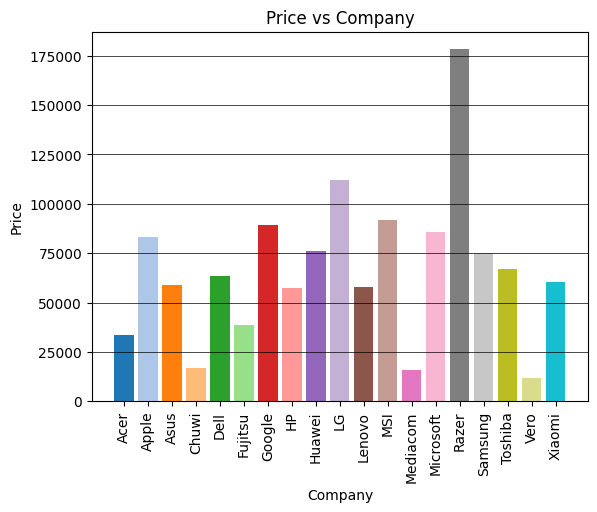

In [194]:


counts = data.groupby('Company')['Price'].mean()

colors = plt.cm.tab20(range(len(counts)))

plt.bar(counts.index, counts.values, color=colors,)

plt.xlabel('Company')
plt.ylabel('Price')
plt.title('Price vs Company')
plt.xticks(rotation=90)

plt.grid(axis='y', linewidth=0.5, color='black')

plt.show()

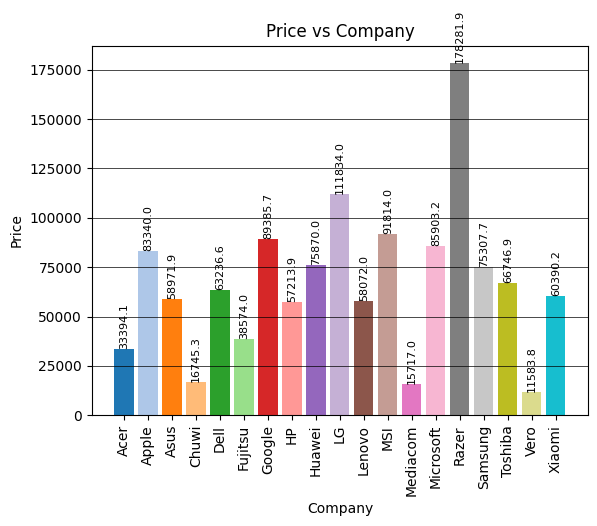

In [196]:


counts = data.groupby('Company')['Price'].mean()

colors = plt.cm.tab20(range(len(counts)))

bars = plt.bar(counts.index, counts.values, color=colors)

plt.xlabel('Company')
plt.ylabel('Price')
plt.title('Price vs Company')
plt.xticks(rotation=90)

# 🎯 ADD VALUES ON TOP
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 1),
             ha='center', va='bottom', fontsize=8, rotation=90)

plt.grid(axis='y', linewidth=0.5, color='black')

plt.show()

In [197]:
data.head()

,Company,Inches,Cpu,Gpu,OpSys,Price,Ram(GB),Weight(KG),SSD,HDD
0,Apple,13.3,Intel Core i5 2.3GHz,Intel Iris Plus Graphics 640,macOS,71378,8,1.37,128,1024
1,Apple,13.3,Intel Core i5 1.8GHz,Intel HD Graphics 6000,macOS,47895,8,1.34,128,1024
2,HP,15.6,Intel Core i5 7200U 2.5GHz,Intel HD Graphics 620,No OS,30636,8,1.86,256,1024
3,Apple,15.4,Intel Core i7 2.7GHz,AMD Radeon Pro 455,macOS,135195,16,1.83,512,1024
4,Apple,13.3,Intel Core i5 3.1GHz,Intel Iris Plus Graphics 650,macOS,96095,8,1.37,256,1024


In [201]:
x_train, x_test, y_train, y_test = train_test_split(data.drop('Price', axis=1), data['Price'], test_size=0.2, random_state=42)

In [202]:
x_train.head()

,Company,Inches,Cpu,Gpu,OpSys,Ram(GB),Weight(KG),SSD,HDD
502,Lenovo,13.9,Intel Core i5 8250U 1.6GHz,Intel UHD Graphics 620,Windows 10,8,1.4,256,1024
416,Dell,13.3,Intel Core i3 6006U 2GHz,Intel HD Graphics 520,Windows 10,4,1.65,128,1024
162,Dell,15.6,Intel Core i5 8250U 1.6GHz,AMD Radeon 520,Windows 10,8,2.13,256,1024
667,HP,15.6,Intel Core i7 7500U 2.7GHz,AMD Radeon 530,Windows 10,8,2.1,1000,1024
792,Lenovo,13.3,Intel Core i7 7500U 2.7GHz,Intel HD Graphics 620,Windows 10,8,1.37,512,1024


In [203]:
y_train.head()

502     85194
416     36709
162     38787
667     39693
792    104961
Name: Price, dtype: int64

In [205]:
y_test.shape

(255,)